Saving Tweets.csv to Tweets (1).csv
Dataset Shape: (14640, 15)
Numerical Columns Used:
Index(['tweet_id', 'airline_sentiment_confidence', 'negativereason_confidence',
       'retweet_count'],
      dtype='object')

Distance-Based Outliers Detected: 732
Density-Based (LOF) Outliers Detected: 633


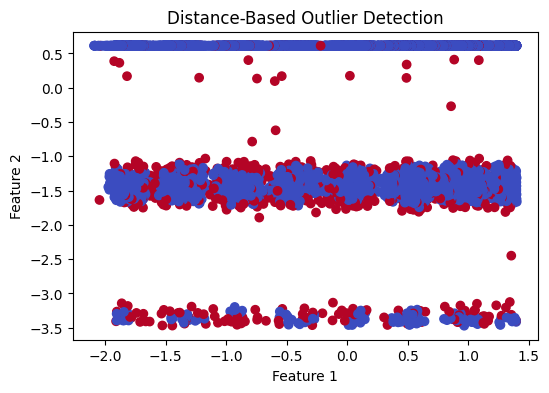

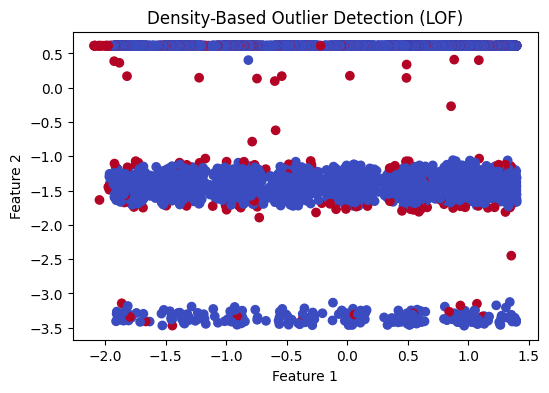

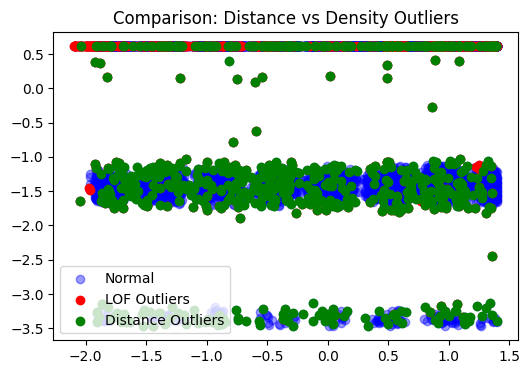

In [2]:
# =====================================
# OUTLIER DETECTION (DISTANCE + DENSITY)
# =====================================

# -------------------------------------
# STEP 1: Import Libraries
# -------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from google.colab import files

# -------------------------------------
# STEP 2: Upload Dataset
# -------------------------------------
uploaded = files.upload()
data = pd.read_csv("Tweets.csv")   # Change filename

print("Dataset Shape:", data.shape)

# -------------------------------------
# STEP 3: Select Numerical Columns
# -------------------------------------
X = data.select_dtypes(include=['int64','float64'])

print("Numerical Columns Used:")
print(X.columns)

# -------------------------------------
# STEP 4: Handle Missing Values (Optional Safety Step)
# -------------------------------------
X = X.fillna(X.mean())

# -------------------------------------
# STEP 5: Feature Scaling
# -------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================
# DISTANCE-BASED OUTLIER DETECTION (KNN)
# =====================================

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

mean_distances = np.mean(distances, axis=1)

threshold = np.percentile(mean_distances, 95)
outliers_distance = mean_distances > threshold

print("\nDistance-Based Outliers Detected:", np.sum(outliers_distance))

# =====================================
# DENSITY-BASED OUTLIER DETECTION (LOF)
# =====================================

lof = LocalOutlierFactor(n_neighbors=20)
lof_labels = lof.fit_predict(X_scaled)

# -1 = outlier, 1 = normal
outliers_lof = lof_labels == -1

print("Density-Based (LOF) Outliers Detected:", np.sum(outliers_lof))

# =====================================
# VISUALIZATION
# =====================================

# Only if dataset has at least 2 numerical columns
if X_scaled.shape[1] >= 2:

    # Distance-Based Plot
    plt.figure(figsize=(6,4))
    plt.scatter(X_scaled[:,0], X_scaled[:,1],
                c=outliers_distance, cmap='coolwarm')
    plt.title("Distance-Based Outlier Detection")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

    # Density-Based Plot
    plt.figure(figsize=(6,4))
    plt.scatter(X_scaled[:,0], X_scaled[:,1],
                c=outliers_lof, cmap='coolwarm')
    plt.title("Density-Based Outlier Detection (LOF)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

    # Comparison Plot
    plt.figure(figsize=(6,4))
    plt.scatter(X_scaled[:,0], X_scaled[:,1],
                c='blue', alpha=0.4, label='Normal')
    plt.scatter(X_scaled[outliers_lof,0],
                X_scaled[outliers_lof,1],
                c='red', label='LOF Outliers')
    plt.scatter(X_scaled[outliers_distance,0],
                X_scaled[outliers_distance,1],
                c='green', label='Distance Outliers')
    plt.legend()
    plt.title("Comparison: Distance vs Density Outliers")
    plt.show()

else:
    print("Dataset needs at least 2 numerical features for visualization.")